## AI Use-Case Design

AI Use-Case Design focuses on identifying a real business problem that can be solved using Artificial Intelligence, selecting an appropriate AI approach, and designing the solution while considering its risks, limitations, and ethical implications.

Building on Project 08's customer segmentation, the identified business problem is:
`Users may struggle to discover movies that match their interests, while the platform needs to increase personalized engagement.`

The proposed AI solution is therefore a:

***Personalized Movie Recommendation System***

The system will analyze user behavior, movie characteristics, and historical ratings to recommend movies that individual users are likely to appreciate.
Unlike Project 08, Project 09 is primarily an AI system-design project.
We are not trying to squeeze another random ML algorithm out of the dataset.
Instead, we're answering:

>What should an actual Data Scientist/AI team build, why should they build it, and how should it work?

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_DIR = Path("../Datasets_MLmodels/ml-latest-small")
P08_DIR = Path("../outputs/recommendation/project08_customer_segmentation")
OUTPUT_DIR = Path("../outputs/recommendation/project09_ai_use_case")

FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
movies = pd.read_csv(DATA_DIR / "movies.csv")
ratings = pd.read_csv(DATA_DIR / "ratings.csv")
tags = pd.read_csv(DATA_DIR / "tags.csv")
links = pd.read_csv(DATA_DIR / "links.csv")

user_segments = pd.read_csv(P08_DIR / "user_segments.csv")

In [4]:
print("Movies :", movies.shape)
print("Ratings:", ratings.shape)
print("Tags   :", tags.shape)
print("Links  :", links.shape)
print("Users  :", user_segments.shape)

Movies : (9742, 3)
Ratings: (100836, 4)
Tags   : (3683, 4)
Links  : (9742, 3)
Users  : (610, 27)


In [5]:
user_segments.head()

,userId,rating_count,avg_rating,rating_std,unique_movies,tag_count,(no genres listed),Action,Adventure,Animation,...,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,cluster
0,1,232,4.366379,0.800048,232,0.0,0.0,0.129125,0.121951,0.041607,...,0.024390,0.000000,0.031564,0.025825,0.037303,0.057389,0.078910,0.031564,0.010043,3
1,2,29,3.948276,0.805615,29,9.0,0.0,0.146667,0.040000,0.000000,...,0.013333,0.053333,0.000000,0.026667,0.013333,0.053333,0.133333,0.013333,0.013333,1
2,3,39,2.435897,2.090642,39,0.0,0.0,0.130841,0.102804,0.037383,...,0.074766,0.000000,0.009346,0.009346,0.046729,0.140187,0.065421,0.046729,0.000000,3
3,4,216,3.555556,1.314204,216,0.0,0.0,0.048544,0.056311,0.011650,...,0.007767,0.001942,0.031068,0.044660,0.112621,0.023301,0.073786,0.013592,0.019417,1
4,5,44,3.636364,0.990441,44,0.0,0.0,0.070312,0.062500,0.046875,...,0.007812,0.023438,0.039062,0.007812,0.085938,0.015625,0.070312,0.023438,0.015625,0


In [6]:
business_problem = """
Movie users are exposed to a large catalog of content.
Without personalization, users may find it difficult to
discover movies matching their interests. The business
therefore needs an intelligent system that can recommend
relevant movies to individual users.
"""

print(business_problem)


Movie users are exposed to a large catalog of content.
Without personalization, users may find it difficult to
discover movies matching their interests. The business
therefore needs an intelligent system that can recommend
relevant movies to individual users.



In [7]:
ai_use_case = {
    "business_problem": "Difficulty discovering relevant movies",
    "ai_solution": "Personalized Movie Recommendation System",
    "primary_goal": "Increase relevance and user engagement",
    "users": "Movie platform users",
    "business_value": "Better content discovery and personalization"
}
pd.DataFrame([ai_use_case])

,business_problem,ai_solution,primary_goal,users,business_value
0,Difficulty discovering relevant movies,Personalized Movie Recommendation System,Increase relevance and user engagement,Movie platform users,Better content discovery and personalization


In [8]:
data_inventory = pd.DataFrame({
    "Dataset": [
        "ratings.csv",
        "movies.csv",
        "tags.csv",
        "links.csv",
        "Project 08 user_segments.csv"
    ],
    "Purpose": [
        "User preference and interaction history",
        "Movie titles and genres",
        "Additional user preference signals",
        "External movie identifiers",
        "User behavioral segments"
    ],
    "AI_Relevance": [
        "High",
        "High",
        "Medium",
        "Low",
        "High"
    ]
})
data_inventory

,Dataset,Purpose,AI_Relevance
0,ratings.csv,User preference and interaction history,High
1,movies.csv,Movie titles and genres,High
2,tags.csv,Additional user preference signals,Medium
3,links.csv,External movie identifiers,Low
4,Project 08 user_segments.csv,User behavioral segments,High


In [9]:
approach_comparison = pd.DataFrame({
    "Approach": [
        "Content-Based",
        "Collaborative Filtering",
        "Hybrid"
    ],
    "Uses_Movie_Features": [
        "Yes",
        "No",
        "Yes"
    ],
    "Uses_User_Behavior": [
        "Limited",
        "Yes",
        "Yes"
    ],
    "Personalization": [
        "High",
        "High",
        "Very High"
    ],
    "Cold_Start_Handling": [
        "Better for new movies",
        "Weak for new users/movies",
        "Better"
    ],
    "Recommended": [
        "No",
        "No",
        "Yes"
    ]
})
approach_comparison
# A hybrid system can exploit both what movies are like and what users actually like.

,Approach,Uses_Movie_Features,Uses_User_Behavior,Personalization,Cold_Start_Handling,Recommended
0,Content-Based,Yes,Limited,High,Better for new movies,No
1,Collaborative Filtering,No,Yes,High,Weak for new users/movies,No
2,Hybrid,Yes,Yes,Very High,Better,Yes


In [10]:
segment_distribution = (
    user_segments["cluster"]
    .value_counts()
    .sort_index()
)
segment_distribution

cluster
0    143
1    207
2     36
3    224
Name: count, dtype: int64

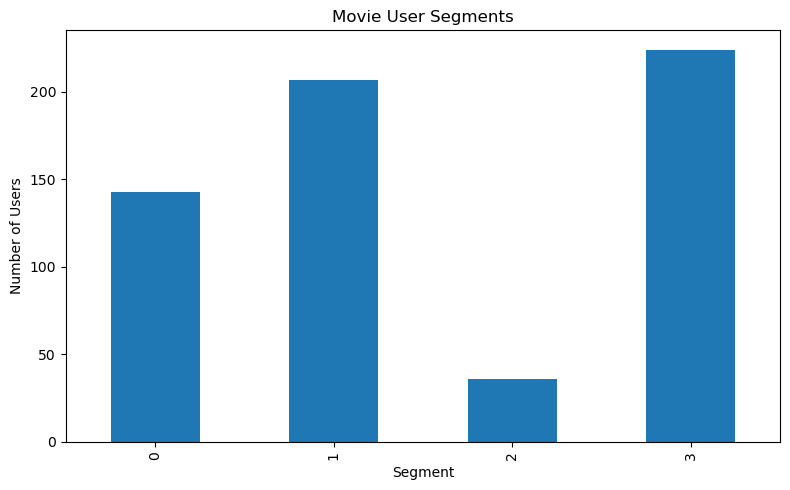

In [11]:
plt.figure(figsize=(8, 5))

segment_distribution.plot(
    kind="bar"
)

plt.title("Movie User Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Users")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "user_segments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
recommendation_inputs = pd.DataFrame({
    "Input": [
        "User rating history",
        "Movie genres",
        "User preferences",
        "User segment",
        "User-generated tags"
    ],
    "Source": [
        "ratings.csv",
        "movies.csv",
        "ratings.csv + movies.csv",
        "Project 08",
        "tags.csv"
    ],
    "Role": [
        "Collaborative filtering",
        "Content-based filtering",
        "Preference modeling",
        "Personalization",
        "Preference enrichment"
    ]
})
recommendation_inputs

,Input,Source,Role
0,User rating history,ratings.csv,Collaborative filtering
1,Movie genres,movies.csv,Content-based filtering
2,User preferences,ratings.csv + movies.csv,Preference modeling
3,User segment,Project 08,Personalization
4,User-generated tags,tags.csv,Preference enrichment


In [13]:
recommendation_workflow = [
    "Collect user interaction history",
    "Process movie metadata",
    "Create user and movie features",
    "Generate candidate movies",
    "Apply collaborative filtering",
    "Apply content-based similarity",
    "Combine recommendation scores",
    "Adjust for user segment",
    "Rank candidate movies",
    "Return Top-N recommendations"
]
for step, process in enumerate(recommendation_workflow,start=1):
    print(f"{step}. {process}")

1. Collect user interaction history
2. Process movie metadata
3. Create user and movie features
4. Generate candidate movies
5. Apply collaborative filtering
6. Apply content-based similarity
7. Combine recommendation scores
8. Adjust for user segment
9. Rank candidate movies
10. Return Top-N recommendations


In [14]:
score_weights = {
    "collaborative": 0.50,
    "content_based": 0.30,
    "segment": 0.20
}
pd.DataFrame([score_weights])

,collaborative,content_based,segment
0,0.5,0.3,0.2


In [15]:
evaluation_metrics = pd.DataFrame({
    "Metric": [
        "Precision@K",
        "Recall@K",
        "NDCG@K",
        "Hit Rate",
        "Coverage",
        "Diversity"
    ],
    "Purpose": [
        "Measure relevant recommendations",
        "Measure relevant items successfully retrieved",
        "Measure ranking quality",
        "Measure whether useful items appear",
        "Measure catalog exposure",
        "Measure variety of recommendations"
    ]
})
evaluation_metrics

,Metric,Purpose
0,Precision@K,Measure relevant recommendations
1,Recall@K,Measure relevant items successfully retrieved
2,NDCG@K,Measure ranking quality
3,Hit Rate,Measure whether useful items appear
4,Coverage,Measure catalog exposure
5,Diversity,Measure variety of recommendations


In [16]:
business_kpis = pd.DataFrame({
    "KPI": [
        "Recommendation Click-Through Rate",
        "Watch/Interaction Rate",
        "User Engagement",
        "Session Duration",
        "Content Discovery",
        "User Retention"
    ],
    "Business_Objective": [
        "Measure recommendation attractiveness",
        "Measure recommendation usefulness",
        "Increase platform activity",
        "Increase time spent discovering content",
        "Expose users to relevant content",
        "Encourage continued usage"
    ]
})
business_kpis

,KPI,Business_Objective
0,Recommendation Click-Through Rate,Measure recommendation attractiveness
1,Watch/Interaction Rate,Measure recommendation usefulness
2,User Engagement,Increase platform activity
3,Session Duration,Increase time spent discovering content
4,Content Discovery,Expose users to relevant content
5,User Retention,Encourage continued usage


In [17]:
ai_risks = pd.DataFrame({
    "Risk": [
        "Popularity Bias",
        "Filter Bubble",
        "Cold Start",
        "Privacy",
        "Lack of Explainability",
        "Feedback Loops"
    ],
    "Potential_Impact": [
        "Popular movies dominate recommendations",
        "Users repeatedly receive similar content",
        "New users/movies have limited data",
        "User behavior could be sensitive",
        "Users may not understand recommendations",
        "Recommendations reinforce existing behavior"
    ]
})
ai_risks

,Risk,Potential_Impact
0,Popularity Bias,Popular movies dominate recommendations
1,Filter Bubble,Users repeatedly receive similar content
2,Cold Start,New users/movies have limited data
3,Privacy,User behavior could be sensitive
4,Lack of Explainability,Users may not understand recommendations
5,Feedback Loops,Recommendations reinforce existing behavior


In [18]:
risk_controls = pd.DataFrame({
    "Risk": [
        "Popularity Bias",
        "Filter Bubble",
        "Cold Start",
        "Privacy",
        "Lack of Explainability",
        "Feedback Loops"
    ],
    "Mitigation": [
        "Include diversity and less-popular relevant content",
        "Introduce controlled content variety",
        "Use content-based and popularity-based fallback",
        "Minimize and protect personal data",
        "Provide recommendation explanations",
        "Continuously monitor recommendation behavior"
    ]
})
risk_controls

,Risk,Mitigation
0,Popularity Bias,Include diversity and less-popular relevant co...
1,Filter Bubble,Introduce controlled content variety
2,Cold Start,Use content-based and popularity-based fallback
3,Privacy,Minimize and protect personal data
4,Lack of Explainability,Provide recommendation explanations
5,Feedback Loops,Continuously monitor recommendation behavior


In [19]:
ethical_principles = pd.DataFrame({
    "Principle": [
        "Privacy",
        "Transparency",
        "Fairness",
        "User Control",
        "Security",
        "Diversity"
    ],
    "Implementation": [
        "Minimize unnecessary user data",
        "Explain why content is recommended",
        "Avoid systematically excluding content",
        "Allow users to influence preferences",
        "Protect stored behavioral data",
        "Avoid excessive repetition of similar content"
    ]
})
ethical_principles

,Principle,Implementation
0,Privacy,Minimize unnecessary user data
1,Transparency,Explain why content is recommended
2,Fairness,Avoid systematically excluding content
3,User Control,Allow users to influence preferences
4,Security,Protect stored behavioral data
5,Diversity,Avoid excessive repetition of similar content


In [20]:
human_oversight = [
    "Monitor recommendation quality",
    "Review unusual recommendation patterns",
    "Audit bias and content exposure",
    "Monitor privacy and security",
    "Allow users to modify preferences",
    "Periodically retrain and evaluate the model"
]
for item in human_oversight:
    print("•", item)

• Monitor recommendation quality
• Review unusual recommendation patterns
• Audit bias and content exposure
• Monitor privacy and security
• Allow users to modify preferences
• Periodically retrain and evaluate the model


In [21]:
solution_specification = {
    "Problem": "Difficulty discovering relevant movies",
    "AI Solution": "Personalized Movie Recommendation System",
    "Primary Approach": "Hybrid Recommendation",
    "Data": "Ratings + Movie Metadata + Tags + User Segments",
    "Personalization": "User Behavior + Preferences + Segment",
    "Output": "Top-N Personalized Movie Recommendations",
    "Evaluation": "Precision@K, Recall@K, NDCG@K, Coverage, Diversity",
    "Business Goal": "Improve content discovery and engagement",
    "Key Risks": "Bias, Privacy, Cold Start, Filter Bubble, Feedback Loops"
}
pd.DataFrame(solution_specification.items(), columns=["Component", "Design"])

,Component,Design
0,Problem,Difficulty discovering relevant movies
1,AI Solution,Personalized Movie Recommendation System
2,Primary Approach,Hybrid Recommendation
3,Data,Ratings + Movie Metadata + Tags + User Segments
4,Personalization,User Behavior + Preferences + Segment
5,Output,Top-N Personalized Movie Recommendations
6,Evaluation,"Precision@K, Recall@K, NDCG@K, Coverage, Diver..."
7,Business Goal,Improve content discovery and engagement
8,Key Risks,"Bias, Privacy, Cold Start, Filter Bubble, Feed..."


In [22]:
data_inventory.to_csv(OUTPUT_DIR / "data_inventory.csv",index=False)

approach_comparison.to_csv(OUTPUT_DIR / "ai_approach_comparison.csv",index=False)

recommendation_inputs.to_csv(OUTPUT_DIR / "recommendation_inputs.csv",index=False)

evaluation_metrics.to_csv(OUTPUT_DIR / "evaluation_metrics.csv",index=False)

business_kpis.to_csv(OUTPUT_DIR / "business_kpis.csv",index=False)

ai_risks.to_csv(OUTPUT_DIR / "ai_risks.csv",index=False)

risk_controls.to_csv(OUTPUT_DIR / "risk_controls.csv", index=False)

ethical_principles.to_csv(OUTPUT_DIR / "ethical_principles.csv",index=False)

### The key conclusion should be:

>MovieLens user behavior can support an AI-powered personalized recommendation system. A hybrid recommendation approach is proposed because it can combine collaborative signals from user ratings with content information from movie genres and additional personalization signals from the customer segments developed in Project 08.